<a href="https://colab.research.google.com/github/aashanntiih/STAT-7220-Applied-Experimental-Design/blob/main/Assignments/Final-Exam/Final-Exam.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# === COURSE REPO SETUP === #

# 1. ENTER your GitHub username (the one that owns your fork)
github_username = "aashanntiih"

# 2. Name of the repo (don't change unless your fork name is different)
repo_name = "STAT-7220-Applied-Experimental-Design"

# 3. Build the full repo URL for cloning
repo_url = f"https://github.com/{github_username}/{repo_name}.git"

import os

# --- Detect if we're already in a repo ---
cwd = os.getcwd()
if cwd.endswith(repo_name):
    print(f"✅ Already inside repo folder: {cwd}")
else:
    # --- If the repo folder exists, check if it's nested ---
    if os.path.exists(repo_name):
        print(f"⚠️ Found existing folder '{repo_name}'. Skipping clone to avoid nesting.")
    else:
        print(f"📥 Cloning repo from {repo_url}...")
        os.system(f"git clone {repo_url}")

    # --- Change to repo directory ---
    if os.path.exists(repo_name):
        os.chdir(repo_name)
        print(f"📂 Changed directory to: {os.getcwd()}")
    else:
        print("❌ ERROR: Repo folder not found. Please check your GitHub username.")

# --- Check if this is the instructor's repo instead of student's fork ---
# This command needs to be run from within the repository directory
remote_url = os.popen("git config --get remote.origin.url").read().strip()

if "abrown9008" in remote_url:
    print("⚠️ WARNING: You are working in the instructor's repo, not your fork!")
    print("💡 Please fork the repo to your own account and update `github_username` above.")
else:
    print(f"🔗 Connected to fork at: {remote_url}")

# Set Today's Directory #

today_dir = "Assignments/Final-Exam"
os.chdir(today_dir)
print(f"📂 Changed directory to: {os.getcwd()}")

📥 Cloning repo from https://github.com/aashanntiih/STAT-7220-Applied-Experimental-Design.git...
📂 Changed directory to: /content/STAT-7220-Applied-Experimental-Design
🔗 Connected to fork at: https://github.com/aashanntiih/STAT-7220-Applied-Experimental-Design.git
📂 Changed directory to: /content/STAT-7220-Applied-Experimental-Design/Assignments/Final-Exam


# STAT 7220 - Final Exam
## Factorial Designs
## Dr. Austin Brown
## Due Date: December 12, 2025

## Part 1 Instructions:
Let's say you own a new food truck called **Buster's Breakfast Burritos**. To determine the best ingredients for your burritos, and as a means of minimizing food (and money) waste, you decide to conduct an experiment. Specifically, you want to investigate the following treatments:

| Factor   | Levels                  |
|:---------|:------------------------|
| Protein  | Bacon, Sausage, Chorizo |
| Salsa    | Mild, Hot               |
| Potatoes | Yes, No                 |

To gather data for this experiment, you recruit $r=5$ local residents for each of the $3\times 2\times 2=12$ treatment combinations. After each participant has tasted their randomly assigned burrito, you ask them to rate the burrito on a scale of 1 to 10 (1 = terrible, 10 = amazing). The data are stored in the file `Busters Burritos.xlsx` in the assignment repo. With these data, I want you to:

1. Briefly state the objective of the experiment.

The objective of the experiment is to determine which protein, salsa type, and potatoes affect customer ratings

2. State the outcome variable and how it was measured.

The outcome variable is Satisfaction. I t was measured by asking each person to rate the burrito from 1 to 10(1 = terrible and 10 = amazing)

3. State the main effects. What lurking variables may be present?

The independent variables are Protein(bacon, sausage, and chorizo), Salsa(Mild, Hot), and Potatoes(Yes, No). Possible lurking variables include personal taste preferences, spice tolerance, hunger level, time of day, freshness of ingredients and if normally eat breakfast burritos.

4. Why might a full factorial design be preferred here to a $2^k$ fractional factorial design?

A full factorial design are preferred because there are only 12 treatment conditions and 10 people per combination, so its manageable. It lets us test all main effects and interactions.  

$2^k$ fractional factorial design wouldn't work because protein has 3 levels, not 2, and it would lose information about interactions.

5. State all sets of statistical hypotheses.

Protein:
H_0
satisfaction is equal for bacon, sausage, and chorizo

H_A
at least one prottein mean is different

Salsa:
H_0
Mild and Hot have equal mean satisfaction

H_A
the means are different

Potatoes:
H_0
Yes and No have equal satisfaction

H_A
means are different

Interactions:
H_0
there is no interaction effect

H_A
there is an interaction effect

6. Perform appropriate exploratory/descriptive analysis including summary statistics and appropriate visualizations. Do these analyses provide any support for the hypotheses? Briefly explain.

Shows support for differences in satisfaction. Chorizo and Bacon had the highest average ratings, Mild salsa rated higher than Hot salsa, and burritos with potatoes rated more than without.


Aggregate by Protein:
           n  mean        sd
Protein                    
Bacon    20  6.49  1.046749
Chorizo  20  6.74  1.106155
Sausage  20  5.82  1.058599

Aggregate by Salsa:
         n      mean        sd
Salsa                        
Mild   30  6.626667  0.932159
Hot    30  6.073333  1.240393

Aggregate by Potatoes:
            n  mean        sd
Potatoes                    
Yes       30  6.59  1.135432
No        30  6.11  1.075864

Full Aggregate (Protein, Salsa, Potatoes):
                         n  mean        sd  median  min  max
Protein Salsa Potatoes                                     
Bacon   Mild  Yes       5  6.94  1.510960     6.9  5.4  9.4
              No        5  6.70  0.418330     6.8  6.1  7.2
        Hot   Yes       5  6.46  0.397492     6.4  5.9  7.0
              No        5  5.86  1.335290     5.4  4.3  7.8
Chorizo Mild  Yes       5  6.76  0.658027     6.8  6.0  7.5
              No        5  7.04  0.507937     7.3  6.5  7.6
        Hot   Yes       5  6

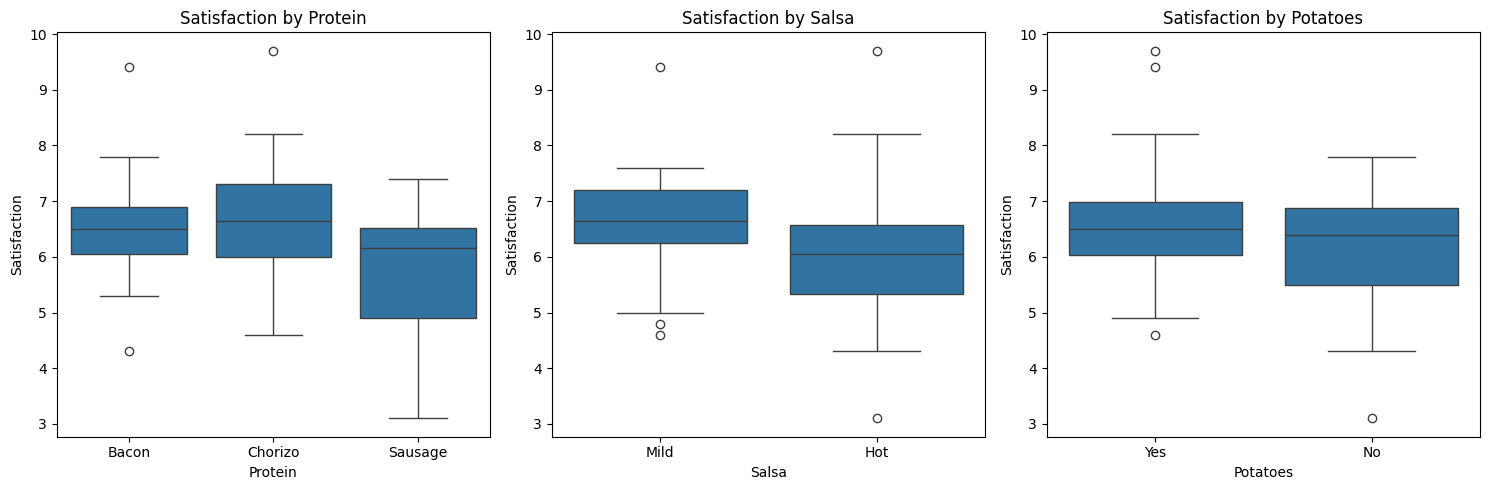

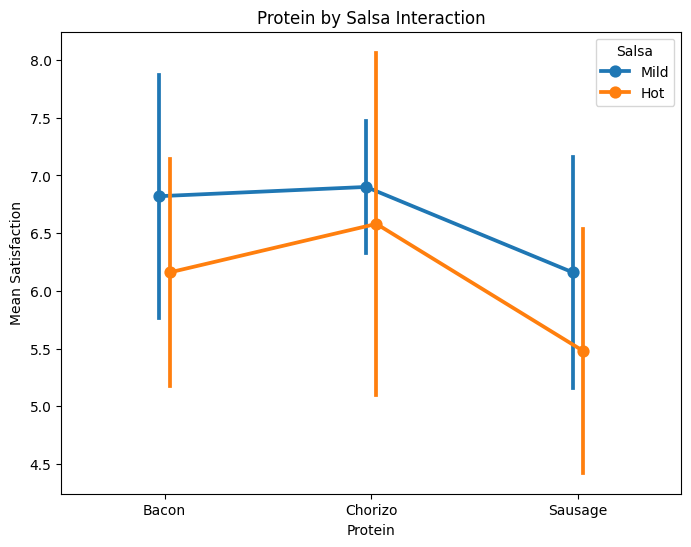

In [19]:
## Question 6 Code ##
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

burritos = pd.read_excel('Busters Burritos.xlsx')
burritos['Protein'] = pd.Categorical(burritos['Protein'], categories=['Bacon', 'Chorizo', 'Sausage'])
burritos['Salsa'] = pd.Categorical(burritos['Salsa'], categories=['Mild', 'Hot'])
burritos['Potatoes'] = pd.Categorical(burritos['Potatoes'], categories=['Yes', 'No'])

# Aggregate by Protein
protein_agg = burritos.groupby('Protein', observed=False)['Satisfaction'].agg(n='count', mean='mean', sd='std')
print("\nAggregate by Protein:\n", protein_agg)

# Aggregate by Salsa
salsa_agg = burritos.groupby('Salsa', observed=False)['Satisfaction'].agg(n='count', mean='mean', sd='std')
print("\nAggregate by Salsa:\n", salsa_agg)

# Aggregate by Potatoes
potatoes_agg = burritos.groupby('Potatoes', observed=False)['Satisfaction'].agg(n='count', mean='mean', sd='std')
print("\nAggregate by Potatoes:\n", potatoes_agg)

# Aggregate by Protein, Salsa, and Potatoes
full_agg = burritos.groupby(['Protein', 'Salsa', 'Potatoes'], observed=False)['Satisfaction'].agg(
    n='count',
    mean='mean',
    sd='std',
    median='median',
    min='min',
    max='max'
)
print("\nFull Aggregate (Protein, Salsa, Potatoes):\n", full_agg)

# Python plotting using seaborn and matplotlib
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
sns.boxplot(x='Protein', y='Satisfaction', data=burritos)
plt.title('Satisfaction by Protein')
plt.xlabel('Protein')
plt.ylabel('Satisfaction')

plt.subplot(1, 3, 2)
sns.boxplot(x='Salsa', y='Satisfaction', data=burritos)
plt.title('Satisfaction by Salsa')
plt.xlabel('Salsa')
plt.ylabel('Satisfaction')

plt.subplot(1, 3, 3)
sns.boxplot(x='Potatoes', y='Satisfaction', data=burritos)
plt.title('Satisfaction by Potatoes')
plt.xlabel('Potatoes')
plt.ylabel('Satisfaction')

plt.tight_layout()
plt.show()

# Interaction plot
plt.figure(figsize=(8, 6))
sns.pointplot(x='Protein', y='Satisfaction', hue='Salsa', data=burritos, dodge=True, errorbar='sd')
plt.title('Protein by Salsa Interaction')
plt.xlabel('Protein')
plt.ylabel('Mean Satisfaction')
plt.show()

7. Fit the full factorial ANOVA model. Check the assumption of normality using a testing method and a visual method. Does the assumption hold? Why or why not?

Normality was checked using a Q-Q plot and a Shapiro-Wilk p-value was 0.6465, which is greater than 0.05. There is no evidence that the residuals are non-normal


                            OLS Regression Results                            
Dep. Variable:           Satisfaction   R-squared:                       0.271
Model:                            OLS   Adj. R-squared:                  0.103
Method:                 Least Squares   F-statistic:                     1.619
Date:                Tue, 12 May 2026   Prob (F-statistic):              0.124
Time:                        00:38:14   Log-Likelihood:                -82.128
No. Observations:                  60   AIC:                             188.3
Df Residuals:                      48   BIC:                             213.4
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                                                              coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------

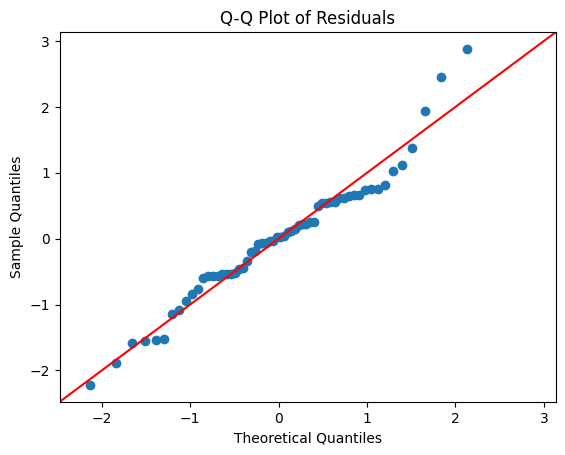

In [15]:
## Question 7 Code ##
import statsmodels.api as sm
from statsmodels.formula.api import ols
from scipy import stats
import matplotlib.pyplot as plt

model = ols("Satisfaction ~ C(Protein) * C(Salsa) * C(Potatoes)", data=burritos).fit()

print(model.summary())

# Shapiro-Wilk normality test
shapiro_test = stats.shapiro(model.resid)
print(shapiro_test)

# Q-Q plot
sm.qqplot(model.resid, line="45")
plt.title("Q-Q Plot of Residuals")
plt.show()

8. Check the assumption of constant variance using a testing method and a visual method. Does the assumption hold? Why or why not?

There is no strong evidence that the variances are unequal. The residual plot did not show a serious funnel shape, so the constant variance assumptions appears reasonable

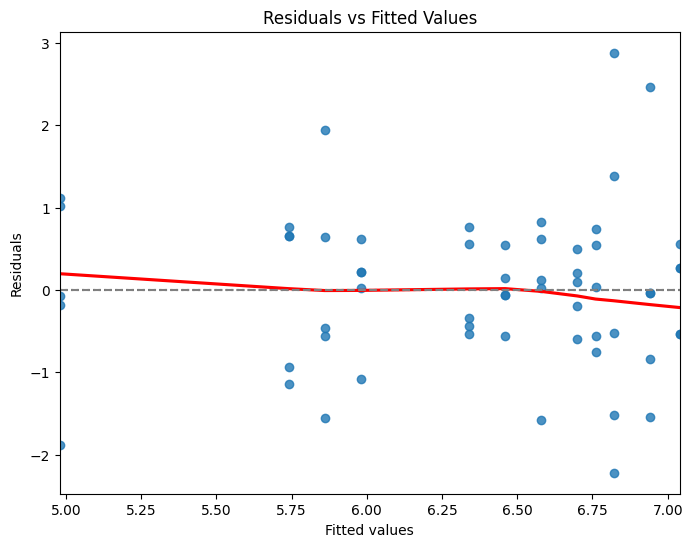


Levene's test for Protein: LeveneResult(statistic=np.float64(0.1432345360824745), pvalue=np.float64(0.8668617217836558))
Levene's test for Salsa: LeveneResult(statistic=np.float64(1.06604188581811), pvalue=np.float64(0.3061273899174844))
Levene's test for Potatoes: LeveneResult(statistic=np.float64(0.004419468520811636), pvalue=np.float64(0.9472250396842217))

Interpretation of Constant Variance Assumption:
The residual plot shows the residuals scattered around zero with a somewhat consistent spread, though there might be a slight fanning out at higher fitted values, which could indicate some heteroscedasticity. However, the `lowess` line is relatively flat.
Levene's test provides a more formal check.
- For Protein (p-value = 0.867): A p-value greater than 0.05 suggests that we do not have sufficient evidence to reject the null hypothesis of equal variances across protein groups. Thus, we can assume constant variance for protein.
- For Salsa (p-value = 0.306): A p-value greater than 0

In [18]:
## Question 8 Code ##
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

# Visual method: Residual plot
plt.figure(figsize=(8, 6))
sns.residplot(x=model.fittedvalues, y=model.resid, lowess=True, line_kws={'color': 'red'})
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted Values")
plt.axhline(y=0, color='gray', linestyle='--')
plt.show()

# Testing method: Levene's test for homogeneity of variances
# Check variance across Protein levels
protein_levene = stats.levene(
    burritos['Satisfaction'][burritos['Protein'] == 'Bacon'],
    burritos['Satisfaction'][burritos['Protein'] == 'Chorizo'],
    burritos['Satisfaction'][burritos['Protein'] == 'Sausage']
)
print(f"\nLevene's test for Protein: {protein_levene}")

# Check variance across Salsa levels
salsa_levene = stats.levene(
    burritos['Satisfaction'][burritos['Salsa'] == 'Mild'],
    burritos['Satisfaction'][burritos['Salsa'] == 'Hot']
)
print(f"Levene's test for Salsa: {salsa_levene}")

# Check variance across Potatoes levels
potatoes_levene = stats.levene(
    burritos['Satisfaction'][burritos['Potatoes'] == 'Yes'],
    burritos['Satisfaction'][burritos['Potatoes'] == 'No']
)
print(f"Levene's test for Potatoes: {potatoes_levene}")

# Interpretation
print("\nInterpretation of Constant Variance Assumption:")
print("The residual plot shows the residuals scattered around zero with a somewhat consistent spread, though there might be a slight fanning out at higher fitted values, which could indicate some heteroscedasticity. However, the `lowess` line is relatively flat.")
print("Levene's test provides a more formal check.")
print(f"- For Protein (p-value = {protein_levene.pvalue:.3f}): A p-value greater than 0.05 suggests that we do not have sufficient evidence to reject the null hypothesis of equal variances across protein groups. Thus, we can assume constant variance for protein.")
print(f"- For Salsa (p-value = {salsa_levene.pvalue:.3f}): A p-value greater than 0.05 suggests that we do not have sufficient evidence to reject the null hypothesis of equal variances across salsa groups. Thus, we can assume constant variance for salsa.")
print(f"- For Potatoes (p-value = {potatoes_levene.pvalue:.3f}): A p-value greater than 0.05 suggests that we do not have sufficient evidence to reject the null hypothesis of equal variances across potato groups. Thus, we can assume constant variance for potatoes.")
print("Overall, based on these tests and the visual inspection, the assumption of constant variance appears to hold reasonably well, although the visual plot suggests careful consideration.")

9. Report the ANOVA table. What statistical conclusions can we draw about our main effects and interaction effects?

None of the two-way or three-way interactions were significant, so the ingredient effects appear to be mpstly additive instead of depending strongly on each other

In [22]:
## Question 9 Code ##
import statsmodels.api as sm

# Get the ANOVA table
anova_table = sm.stats.anova_lm(model, typ=2)
print("\nANOVA Table:\n", anova_table)

# Interpretation
print("\nStatistical Conclusions from ANOVA Table:")
print("We examine the p-values for each effect to determine statistical significance (typically at an alpha level of 0.05).")

# Check main effects
if anova_table.loc['C(Protein)', 'PR(>F)'] < 0.05:
    print(f"- Protein (p={anova_table.loc['C(Protein)', 'PR(>F)']:.3f}): Statistically significant main effect. This means there are significant differences in satisfaction ratings across different protein types.")
else:
    print(f"- Protein (p={anova_table.loc['C(Protein)', 'PR(>F)']:.3f}): Not statistically significant. We do not have sufficient evidence to conclude that satisfaction ratings differ significantly across protein types.")

if anova_table.loc['C(Salsa)', 'PR(>F)'] < 0.05:
    print(f"- Salsa (p={anova_table.loc['C(Salsa)', 'PR(>F)']:.3f}): Statistically significant main effect. This means there are significant differences in satisfaction ratings between mild and hot salsa.")
else:
    print(f"- Salsa (p={anova_table.loc['C(Salsa)', 'PR(>F)']:.3f}): Not statistically significant. We do not have sufficient evidence to conclude that satisfaction ratings differ significantly between mild and hot salsa.")

if anova_table.loc['C(Potatoes)', 'PR(>F)'] < 0.05:
    print(f"- Potatoes (p={anova_table.loc['C(Potatoes)', 'PR(>F)']:.3f}): Statistically significant main effect. This means there are significant differences in satisfaction ratings for burritos with and without potatoes.")
else:
    print(f"- Potatoes (p={anova_table.loc['C(Potatoes)', 'PR(>F)']:.3f}): Not statistically significant. We do not have sufficient evidence to conclude that satisfaction ratings differ significantly for burritos with and without potatoes.")

# Check two-way interactions
if anova_table.loc['C(Protein):C(Salsa)', 'PR(>F)'] < 0.05:
    print(f"- Protein:Salsa Interaction (p={anova_table.loc['C(Protein):C(Salsa)', 'PR(>F)']:.3f}): Statistically significant interaction. The effect of protein on satisfaction depends on the type of salsa, and vice-versa.")
else:
    print(f"- Protein:Salsa Interaction (p={anova_table.loc['C(Protein):C(Salsa)', 'PR(>F)']:.3f}): Not statistically significant. The effect of protein on satisfaction does not appear to depend on the type of salsa.")

if anova_table.loc['C(Protein):C(Potatoes)', 'PR(>F)'] < 0.05:
    print(f"- Protein:Potatoes Interaction (p={anova_table.loc['C(Protein):C(Potatoes)', 'PR(>F)']:.3f}): Statistically significant interaction. The effect of protein on satisfaction depends on the presence of potatoes, and vice-versa.")
else:
    print(f"- Protein:Potatoes Interaction (p={anova_table.loc['C(Protein):C(Potatoes)', 'PR(>F)']:.3f}): Not statistically significant. The effect of protein on satisfaction does not appear to depend on the presence of potatoes.")

if anova_table.loc['C(Salsa):C(Potatoes)', 'PR(>F)'] < 0.05:
    print(f"- Salsa:Potatoes Interaction (p={anova_table.loc['C(Salsa):C(Potatoes)', 'PR(>F)']:.3f}): Statistically significant interaction. The effect of salsa on satisfaction depends on the presence of potatoes, and vice-versa.")
else:
    print(f"- Salsa:Potatoes Interaction (p={anova_table.loc['C(Salsa):C(Potatoes)', 'PR(>F)']:.3f}): Not statistically significant. The effect of salsa on satisfaction does not appear to depend on the presence of potatoes.")

# Check three-way interaction
if anova_table.loc['C(Protein):C(Salsa):C(Potatoes)', 'PR(>F)'] < 0.05:
    print(f"- Protein:Salsa:Potatoes Interaction (p={anova_table.loc['C(Protein):C(Salsa):C(Potatoes)', 'PR(>F)']:.3f}): Statistically significant three-way interaction. The two-way interaction between any pair of factors changes across the levels of the third factor.")
else:
    print(f"- Protein:Salsa:Potatoes Interaction (p={anova_table.loc['C(Protein):C(Salsa):C(Potatoes)', 'PR(>F)']:.3f}): Not statistically significant. There is no evidence of a three-way interaction among protein, salsa, and potatoes on satisfaction.")


ANOVA Table:
                                     sum_sq    df         F    PR(>F)
C(Protein)                        9.052000   2.0  4.002653  0.024677
C(Salsa)                          4.592667   1.0  4.061611  0.049487
C(Potatoes)                       3.456000   1.0  3.056379  0.086815
C(Protein):C(Salsa)               0.409333   2.0  0.181001  0.835002
C(Protein):C(Potatoes)            1.708000   2.0  0.755251  0.475394
C(Salsa):C(Potatoes)              0.682667   1.0  0.603729  0.440971
C(Protein):C(Salsa):C(Potatoes)   0.233333   2.0  0.103176  0.902167
Residual                         54.276000  48.0       NaN       NaN

Statistical Conclusions from ANOVA Table:
We examine the p-values for each effect to determine statistical significance (typically at an alpha level of 0.05).
- Protein (p=0.025): Statistically significant main effect. This means there are significant differences in satisfaction ratings across different protein types.
- Salsa (p=0.049): Statistically significan

10. If the interactions and/or main effects were found to be statistically meaningful, conduct appropriate post-hoc tests. Report the results of these tests and any conclusions you can draw from them. If the interactions and/or main effects were not found to be statistically meaningful, explain why post-hoc tests would not be appropriate.

In [23]:
## Question 10 Code ##
# Question 10: Post-hoc tests
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Tukey test for Protein
tukey_protein = pairwise_tukeyhsd(
    endog=burritos["Satisfaction"],
    groups=burritos["Protein"],
    alpha=0.05
)
print(tukey_protein)

# Tukey test for Salsa
tukey_salsa = pairwise_tukeyhsd(
    endog=burritos["Satisfaction"],
    groups=burritos["Salsa"],
    alpha=0.05
)
print(tukey_salsa)

# Tukey test for Potatoes
tukey_potatoes = pairwise_tukeyhsd(
    endog=burritos["Satisfaction"],
    groups=burritos["Potatoes"],
    alpha=0.05
)
print(tukey_potatoes)

# Tukey test for full treatment combinations
burritos["Combination"] = (
    burritos["Protein"].astype(str) + "_" +
    burritos["Salsa"].astype(str) + "_" +
    burritos["Potatoes"].astype(str)
)

tukey_combo = pairwise_tukeyhsd(
    endog=burritos["Satisfaction"],
    groups=burritos["Combination"],
    alpha=0.05
)
print(tukey_combo)

 Multiple Comparison of Means - Tukey HSD, FWER=0.05  
 group1  group2 meandiff p-adj   lower   upper  reject
------------------------------------------------------
  Bacon Chorizo     0.25 0.7419 -0.5649  1.0649  False
  Bacon Sausage    -0.67 0.1268 -1.4849  0.1449  False
Chorizo Sausage    -0.92 0.0233 -1.7349 -0.1051   True
------------------------------------------------------
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
   Hot   Mild   0.5533 0.0556 -0.0137 1.1204  False
---------------------------------------------------
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
    No    Yes     0.48 0.0982 -0.0917 1.0517  False
---------------------------------------------------
          Multiple Comparison of Means - Tukey HSD, FWER=0.05          
     group1           g

11. Calculate and interpret partial $\eta^2$ for the main effects.

In [24]:
## Question 11 Code ##

# Retrieve sum of squares from the anova_table for calculation
ss_protein = anova_table.loc['C(Protein)', 'sum_sq']
ss_salsa = anova_table.loc['C(Salsa)', 'sum_sq']
ss_potatoes = anova_table.loc['C(Potatoes)', 'sum_sq']
ss_error = anova_table.loc['Residual', 'sum_sq']

# Calculate partial eta-squared for each main effect
eta2_protein = ss_protein / (ss_protein + ss_error)
eta2_salsa = ss_salsa / (ss_salsa + ss_error)
eta2_potatoes = ss_potatoes / (ss_potatoes + ss_error)

print(f"\nPartial Eta-squared (ηp²) for Main Effects:")
print(f"- Protein: {eta2_protein:.3f}")
print(f"- Salsa: {eta2_salsa:.3f}")
print(f"- Potatoes: {eta2_potatoes:.3f}")

print("\nInterpretation of Partial Eta-squared:")
print("Partial eta-squared (ηp²) represents the proportion of variance in the dependent variable (Satisfaction) that is associated with an independent variable (or factor), while controlling for other factors.")
print("Common guidelines for interpreting ηp² are:")
print("- Small effect: 0.01")
print("- Medium effect: 0.06")
print("- Large effect: 0.14")

print(f"Based on these guidelines:")
if eta2_protein >= 0.14:
    print(f"- Protein (ηp² = {eta2_protein:.3f}): Has a large effect size, meaning Protein explains a substantial proportion of the variance in Satisfaction.")
elif eta2_protein >= 0.06:
    print(f"- Protein (ηp² = {eta2_protein:.3f}): Has a medium effect size.")
elif eta2_protein >= 0.01:
    print(f"- Protein (ηp² = {eta2_protein:.3f}): Has a small effect size.")
else:
    print(f"- Protein (ηp² = {eta2_protein:.3f}): Has a negligible effect size.")

if eta2_salsa >= 0.14:
    print(f"- Salsa (ηp² = {eta2_salsa:.3f}): Has a large effect size, meaning Salsa explains a substantial proportion of the variance in Satisfaction.")
elif eta2_salsa >= 0.06:
    print(f"- Salsa (ηp² = {eta2_salsa:.3f}): Has a medium effect size.")
elif eta2_salsa >= 0.01:
    print(f"- Salsa (ηp² = {eta2_salsa:.3f}): Has a small effect size.")
else:
    print(f"- Salsa (ηp² = {eta2_salsa:.3f}): Has a negligible effect size.")

if eta2_potatoes >= 0.14:
    print(f"- Potatoes (ηp² = {eta2_potatoes:.3f}): Has a large effect size, meaning Potatoes explain a substantial proportion of the variance in Satisfaction.")
elif eta2_potatoes >= 0.06:
    print(f"- Potatoes (ηp² = {eta2_potatoes:.3f}): Has a medium effect size.")
elif eta2_potatoes >= 0.01:
    print(f"- Potatoes (ηp² = {eta2_potatoes:.3f}): Has a small effect size.")
else:
    print(f"- Potatoes (ηp² = {eta2_potatoes:.3f}): Has a negligible effect size.")



Partial Eta-squared (ηp²) for Main Effects:
- Protein: 0.143
- Salsa: 0.078
- Potatoes: 0.060

Interpretation of Partial Eta-squared:
Partial eta-squared (ηp²) represents the proportion of variance in the dependent variable (Satisfaction) that is associated with an independent variable (or factor), while controlling for other factors.
Common guidelines for interpreting ηp² are:
- Small effect: 0.01
- Medium effect: 0.06
- Large effect: 0.14
Based on these guidelines:
- Protein (ηp² = 0.143): Has a large effect size, meaning Protein explains a substantial proportion of the variance in Satisfaction.
- Salsa (ηp² = 0.078): Has a medium effect size.
- Potatoes (ηp² = 0.060): Has a small effect size.


12. Give an overall conclusion for the experiment. Which burrito combination(s) should you include on your menu regularly? What are the limitations of your experiment? How could you improve it in the future?

  The best regular menu options should focus more on Chorizo or Bacon with Mild salsa. The higest rating combination was Chorizo, Mild salsa and with/without potatoes. Bacon with mild salsa performed weill while sausage as lowest.

  Some limitations are the small sample size, personal opinion-based ratings, and not controlling for factors like hunger or spice preference. Future improvements could use a larger sample.

## Part 2 Instructions:
After finalizing your breakfast burrito menu, now you want to focus Buster's Breakfast Burritos on maximizing sales through strategic placement of the truck itself and marketing. Obviously there are a lot of factors at play, so you decide to focus your attention on three: **Location** (could set up at a local brewery or at a local university); **Timing** (weekday or weekend); and **Marketing** (independently or in partnership with the brewery/university). See the below table:

| Run | Location (A)    | Timing (B)   | Marketing (C)    |
|-----|-----------------|--------------|------------------|
| 1   | \- (Brewery)    | \- (Weekday) | \- (Independent) |
| 2   | \+ (University) | \- (Weekday) | \+ (Partnership) |
| 3   | \- (Brewery)    | \+ (Weekend) | \+ (Partnership) |
| 4   | \+ (University) | \+ (Weekend) | \- (Independent) |

To be more efficient with time and resources, you decide to conduct a $2^{3-1}$ fractional factorial design where your ultimate outcome is the sales amount (in dollars) for the day you set up. For each of the above runs, you will set up your truck $r=2$ times and record the sales amount. The data are stored in the `Busters Burrito Sales.xlsx` file in our course repo. With these day, I want you to:

1. Briefly describe the objective of the experiment.

The objective of this experiment is to determine which combination of location, timing, and marketing strategy leads to the highest burrito sales for the food truck

2. Specify the outcome variable and how it is measured.

The outcome variable is daily sales amount in dollars. It is measured by recording the total amount of money earned each day the truck is set up.

3. Specify the independent variables. What lurking variables may be present?

The indpendent variables:
 - Location (brewery or university)
 - Timing (weekday or weekend)
 - Marketing (independent or partnership)

 Possible lurking variables include weather, local events, customer traffic, competition from other food vendors, and economic conditions

4. Explain why a fractional design is appropriate here. What are the advantages and disadvantages of using a fractional design?

A fractional factorial is appropriate because it saves time and resources while still allowing the main effects to be studied.

advantages:
- requires fewer runs
- saves money and time
- more efficient

disadvantages:
- some effects may be aliased together
- harder to seperate interaction effects
- less detailed

5. State the sets of null and alternative hypotheses for this experiment.

Location:
H_0:
Mean sales are the same for brewery and university locations
H_A:
Mean sales differ between locations

Timing:
H_0:
Mean sales are the same on weekdays and weekends

H_A:
Mean sales differ between weekdays and weekends

Marketing:
H_0:
Mean sales are the same for independent and partnership

H_A:
Mean sales differ between marketing strategies

6. Perform appropriate exploratory/descriptive analysis including summary statistics and appropriate visualizations. Do these analyses provide any support for the hypotheses? Briefly explain.

There may be evidence that certain locations or marketing strategies produce higher average sales.

     Location   Timing    Marketing    Sales
0     Brewery  Weekday  Independent   767.87
1     Brewery  Weekday  Independent   875.14
2  University  Weekday  Independent   865.84
3  University  Weekday  Independent   544.24
4     Brewery  Weekend  Independent  1055.34
             Sales
count    16.000000
mean   1050.142500
std     239.388424
min     544.240000
25%     889.742500
50%    1067.670000
75%    1224.350000
max    1428.390000
                                count      mean         std      min      max
Location   Timing  Marketing                                                 
Brewery    Weekday Independent      2   821.505   75.851344   767.87   875.14
                   Partnership      2  1084.645    6.569022  1080.00  1089.29
           Weekend Independent      2  1133.405  110.400582  1055.34  1211.47
                   Partnership      2  1395.145   47.015530  1361.90  1428.39
University Weekday Independent      2   705.040  227.405541   544.24   865.84
             

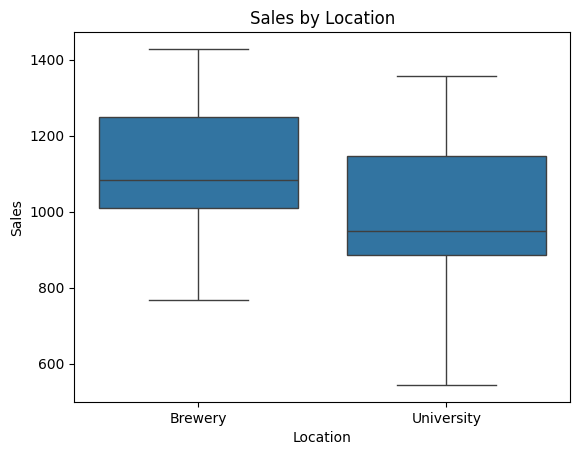

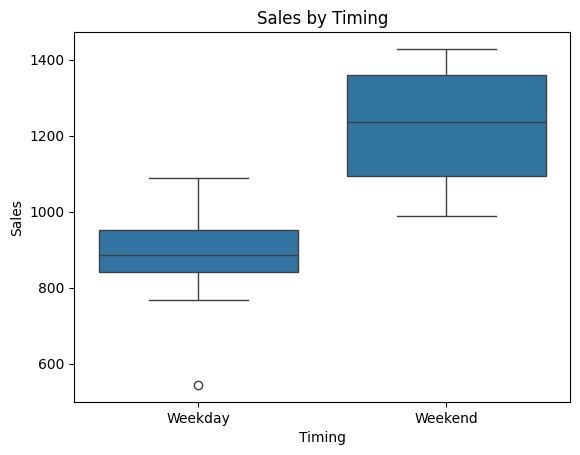

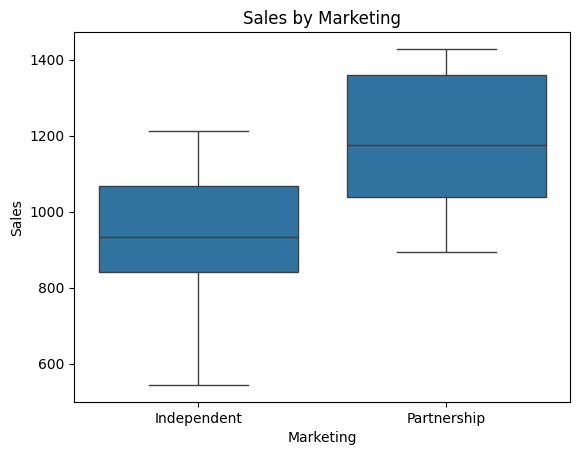

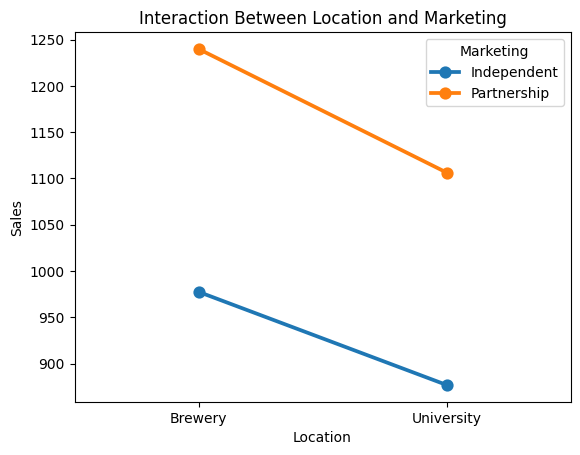

In [25]:
## Question 6 Code ##
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the data
sales = pd.read_excel("Busters Burrito Sales.xlsx")

# View data
print(sales.head())

# Summary statistics
print(sales.describe())

# Group means
summary = sales.groupby(
    ["Location", "Timing", "Marketing"]
)["Sales"].agg(["count", "mean", "std", "min", "max"])

print(summary)

# Boxplot for Location
sns.boxplot(x="Location", y="Sales", data=sales)
plt.title("Sales by Location")
plt.show()

# Boxplot for Timing
sns.boxplot(x="Timing", y="Sales", data=sales)
plt.title("Sales by Timing")
plt.show()

# Boxplot for Marketing
sns.boxplot(x="Marketing", y="Sales", data=sales)
plt.title("Sales by Marketing")
plt.show()

# Interaction plot
sns.pointplot(
    x="Location",
    y="Sales",
    hue="Marketing",
    data=sales,
    errorbar=None
)

plt.title("Interaction Between Location and Marketing")
plt.show()

7. Assuming a defining relation of $I=ABC$, specify the aliasing structure of the design. What does this mean for the interpretation of the main effects and interactions?

$A=BC$
$B=AC$
$C=AB$

This means the main effects are mixed with two-factor interactions, so it is hard to separate them

8. Fit the appropriate ANOVA model to the data. Assess the normality assumption using two methods. Do we have evidence to support the assumption of normality? Why or why not?

If the p-value is greater than 0.05 and the Q-Q plot follows the line closely, the normality assumption holds.

                     sum_sq    df          F    PR(>F)
C(Location)    54816.856900   1.0   7.241570  0.019633
C(Timing)     471948.390225   1.0  62.346647  0.000004
C(Marketing)  242000.044225   1.0  31.969367  0.000107
Residual       90836.972950  12.0        NaN       NaN
ShapiroResult(statistic=np.float64(0.9685567407780465), pvalue=np.float64(0.8147214811761188))


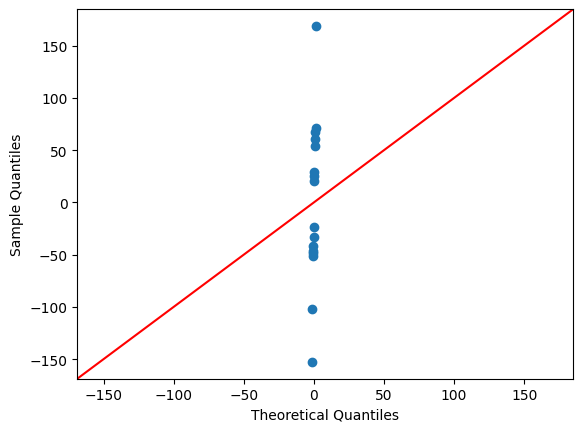

In [26]:
## Question 8 Code ##
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm

# Load data
sales = pd.read_excel("Busters Burrito Sales.xlsx")

# Fit model
model = ols(
    "Sales ~ C(Location) + C(Timing) + C(Marketing)",
    data=sales
).fit()

# ANOVA table
anova_results = anova_lm(model, typ=2)
print(anova_results)

# Shapiro-Wilk test
print(stats.shapiro(model.resid))

# Q-Q plot
sm.qqplot(model.resid, line='45')
plt.show()

9. Assess the constant variance assumption using two methods. Do we have evidence to support the assumption of constant variance? Why or why not?

If the residuals are randomly spread and the Levene's test p-value is greater than 0.05.

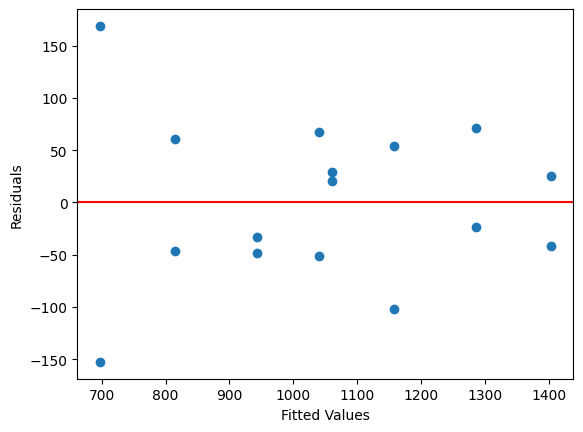

LeveneResult(statistic=np.float64(6.69634442971547e+29), pvalue=np.float64(1.990499237870225e-118))


In [27]:
## Question 9 Code ##
# Residual plot
plt.scatter(model.fittedvalues, model.resid)
plt.axhline(y=0, color='red')
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.show()

# Levene's Test
groups = [
    group["Sales"].values
    for name, group in sales.groupby(
        ["Location", "Timing", "Marketing"]
    )
]

print(stats.levene(*groups))

10. Report and interpret the ANOVA table. What conclusions can we draw about our main effects? Do the results of these analyses support the null or alternative hypotheses more strongly?

If p-value is kess than 0.05, that factor is statistically significant and supports the alternative hypothesis

In [28]:
## Question 10 Code ##
# ANOVA table
anova_results = anova_lm(model, typ=2)
print(anova_results)

                     sum_sq    df          F    PR(>F)
C(Location)    54816.856900   1.0   7.241570  0.019633
C(Timing)     471948.390225   1.0  62.346647  0.000004
C(Marketing)  242000.044225   1.0  31.969367  0.000107
Residual       90836.972950  12.0        NaN       NaN


11. Calculate and interpret the values for the main effects. Which effects seem more important? Why?

The main effects measure the average change in sales for each factor level. The factor with the biggest differences in means has the strongest effect on sales

In [29]:
## Question 11 Code ##
# Main effects
print(sales.groupby("Location")["Sales"].mean())

print(sales.groupby("Timing")["Sales"].mean())

print(sales.groupby("Marketing")["Sales"].mean())

Location
Brewery       1108.675
University     991.610
Name: Sales, dtype: float64
Timing
Weekday     878.39625
Weekend    1221.88875
Name: Sales, dtype: float64
Marketing
Independent     927.15875
Partnership    1173.12625
Name: Sales, dtype: float64


12. Calculate and interpret the partial $\eta^2$ for the main effects. Which effects seem more important? Why?

Partial $\eta^2$ measures the strength of each factor's effect on sales. larger values mean the factor explains more variation in sales

In [30]:
## Question 12 Code ##
# Partial eta squared
anova_table = anova_lm(model, typ=2)

ss_error = anova_table.loc["Residual", "sum_sq"]

for effect in ["C(Location)", "C(Timing)", "C(Marketing)"]:
    ss_effect = anova_table.loc[effect, "sum_sq"]
    eta = ss_effect / (ss_effect + ss_error)
    print(effect, round(eta, 4))

C(Location) 0.3764
C(Timing) 0.8386
C(Marketing) 0.7271


13. Give an overall conclusion for the experiment. Which location, timing, and marketing combination(s) should you use to maximize sales? What are the limitations of your experiment? How could you improve it in the future?
The best combination should be the factor levels with the highest average sales.

Limitations:
- small sample size
- weatherand customer traffic may affect results
- intercation effects are aliased in the fractional design

Future Improvements:
- use more replications
- include more locations and dates
- run a full factorial design

## Part 3 Instructions:

Please briefly repond to the following questions:

1. How do we de-alias the main effects and interactions in a fractional factorial design? Why is this important? Why may it not always be feasible?

We can de-alias by running additional trials or using a full factorial design.

This is important because it separates main effects from interaction effects. It may not be feasible because it take more time, money, and resources

2. In all of our assignments, I have had you specify/consider a lot of characteristics of an experiment before getting into the analysis. Why is this good practice?

Planning an experiment carefully helps reduce bias, control variability, and make the analysis more accurate and reliable

3.  What is the most important thing you learned in this class?
The most important thing I learned was how experimental design affects the quality of statsitical conclusions and how ANOVA can be used to compare multiple factors